# Анализ строительной отрасли (ОКВЭД 41.20)

Задача: собрать датасет самому. Из реестра МСП ФНС взять юрлица, малые и
средние предприятия с ОКВЭД 41.20 "Строительство жилых и нежилых зданий",
по каждой компании достать отчётность из ГИР БФО и оценить перспективность
отрасли через EBITA по годам. Плюс графики роста чистой прибыли и карта
топ-500 компаний по выручке.

Откуда данные:

* реестр МСП - выгрузка с rmsp.nalog.ru, 603 520 строк
* отчётность - bo.nalog.gov.ru, JSON API
* инфляция - ИПЦ Росстата, декабрь к декабрю
* координаты для карты - Photon на данных OpenStreetMap

Что получилось:

* отобрал 10 573 компании
* отчётность нашлась у 10 480 из них, это 99,1%
* 58 342 строки "компания-год" за 2020-2025
* сбалансированная панель: 7 736 компаний, у которых есть все 6 лет

Два шага долгие: чтение xlsx на 85 МБ (около 6 минут) и обход API по всем
компаниям (около 3,5 минут). Оба обёрнуты в проверку `os.path.exists`,
поэтому при повторном запуске данные читаются из готовых CSV.

In [1]:
import csv
import json
import os
import re
import threading
import time
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

ГОДЫ = [2020, 2021, 2022, 2023, 2024, 2025]
ИПЦ = {2020: 4.91, 2021: 8.39, 2022: 11.94, 2023: 7.42, 2024: 9.52, 2025: 5.59}

ИНДЕКС = {}
к = 1.0
for г in ГОДЫ:
    if г > ГОДЫ[0]:
        к *= 1 + ИПЦ[г] / 100
    ИНДЕКС[г] = к

for г, и in ИНДЕКС.items():
    print(f"{г}: индекс цен к 2020 году = {и:.4f}")
print(f"\nнакопленная инфляция 2020 -> 2025: {ИНДЕКС[2025] - 1:+.1%}")

2020: индекс цен к 2020 году = 1.0000
2021: индекс цен к 2020 году = 1.0839
2022: индекс цен к 2020 году = 1.2133
2023: индекс цен к 2020 году = 1.3033
2024: индекс цен к 2020 году = 1.4274
2025: индекс цен к 2020 году = 1.5072

накопленная инфляция 2020 -> 2025: +50.7%


## 1. Реестр ФНС

В выгрузке один лист на 603 520 строк. Что пришлось учесть:

1. Шапка не в первой строке, а в третьей, поэтому `header=2`.
2. `dtype=str` обязателен. Без него ИНН превращается в `7.80119e+09` и для
   запросов к API уже не годится.
3. Код и название ОКВЭД лежат в одной ячейке: "41.20 Строительство жилых и
   нежилых зданий". Код отрезаю через `.str.split(n=1).str[0]`.

В реестре встречаются и 41.20, и 41.2. Название у них одинаковое, это один и
тот же вид деятельности, просто записан с разной точностью, поэтому беру оба
кода: получается на 1 646 компаний больше. Микропредприятия не беру, в задании
только малые и средние.

In [2]:
CSV_РЕЕСТР = "реестр_стройка.csv"

if os.path.exists(CSV_РЕЕСТР):
    reg = pd.read_csv(CSV_РЕЕСТР, dtype=str)
    print(f"прочитано из {CSV_РЕЕСТР}: {len(reg)} компаний")
else:
    df = pd.read_excel("Реестр (1).xlsx", header=2, dtype=str)
    print(f"в реестре всего: {len(df)} строк")

    оквэд = df["Основной вид деятельности"].str.split(n=1).str[0]
    отбор = (
        (df["Тип субъекта"] == "Юридическое лицо")
        & df["Категория"].isin(["Малое предприятие", "Среднее предприятие"])
        & оквэд.isin(["41.20", "41.2"])
    )
    reg = df[отбор].copy()
    reg.to_csv(CSV_РЕЕСТР, index=False, encoding="utf-8-sig")
    print(f"отобрано: {len(reg)}")

print()
print(reg["Категория"].value_counts().to_string())
print("\nтоп-10 регионов:")
print(reg["Регион"].value_counts().head(10).to_string())

прочитано из реестр_стройка.csv: 10573 компаний

Категория
Малое предприятие      9681
Среднее предприятие     892

топ-10 регионов:
Регион
77 - г.Москва                            2187
78 - г.Санкт-Петербург                    852
50 - Московская область                   544
16 - Республика Татарстан (Татарстан)     409
66 - Свердловская область                 355
23 - Краснодарский край                   328
02 - Республика Башкортостан              284
54 - Новосибирская область                258
63 - Самарская область                    249
52 - Нижегородская область                199


Как из 603 тысяч записей получились 10,5 тысячи (считал прямым проходом по
файлу):

* всего в выгрузке 603 520
* юрлиц 402 294, ИП 201 226
* с ОКВЭД 41.20 - 530 132
* юрлица + 41.20 + малые и средние - 8 927
* то же самое, но ещё и с кодом 41.2 - 10 573, эту выборку и беру

## 2. Сбор отчётности из БФО

На сайте bo.nalog.gov.ru карточка компании занимает несколько экранов, но по
факту нужно два запроса:

```
1) GET /advanced-search/organizations/search?query={ИНН}&page=0
   -> content[0]["id"], внутренний номер организации
   -> оттуда же адрес, ОКВЭД, статус

2) GET /nbo/organizations/{org_id}/bfo/
   -> список отчётов по годам, и в каждом сразу все цифры форм
   -> rep["typeCorrections"][0]["correction"]["financialResult"]
```

Отдельный запрос `/details` не нужен, цифры приходят уже в списке отчётов.
Это вдвое сократило время сбора.

Что ещё выяснилось про данные:

* единицы измерения - тысячи рублей. Проверил: `gainSum` из поиска совпадает
  с `current2110` из формы 2
* в БФО лежат 2021-2025, но в каждом отчёте есть колонка предыдущего года
  (`previous*`). Взял её из самого раннего отчёта и получил ещё и 2020-й
* ИНН в ответе поиска приходит с тегами `<strong>`, это подсветка совпадения,
  использовать такое поле нельзя
* скорость - 0,18 секунды на компанию в один поток. На четырёх потоках все
  10 573 компании обходятся за 3,5 минуты. Заголовок `User-Agent` обязателен

Коды формы 2, которые беру:

* 2110 выручка
* 2120 себестоимость, в упрощённой форме это все расходы сразу
* 2200 прибыль от продаж
* 2300 прибыль до налогообложения
* 2330 проценты к уплате
* 2340 и 2350 прочие доходы и расходы
* 2400 чистая прибыль
* 2410 налог на прибыль

In [3]:
BASE = "https://bo.nalog.gov.ru"
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                   "(KHTML, like Gecko) Chrome/126.0 Safari/537.36"),
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "ru-RU,ru;q=0.9",
}
WORKERS = 4
_local = threading.local()


def session():
    if not hasattr(_local, "s"):
        _local.s = requests.Session()
        _local.s.headers.update(HEADERS)
    return _local.s


def get_json(url, попыток=4):
    for i in range(попыток):
        try:
            r = session().get(url, timeout=30)
            if r.status_code == 200:
                return r.json()
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(2 ** i)
                continue
            return None
        except (requests.RequestException, ValueError):
            time.sleep(2 ** i)
    return None


def показатели(отчёты, раздел, коды, база):
    отчёты = sorted(отчёты, key=lambda r: int(r["period"]))
    строки = []
    for i, отчёт in enumerate(отчёты):
        версии = отчёт.get("typeCorrections") or []
        if not версии:
            continue
        данные = (версии[0].get("correction") or {}).get(раздел)
        if not данные:
            continue
        год = int(отчёт["period"])
        строки.append(dict(база, год=год,
                           **{c: данные.get("current" + c) for c in коды}))
        if i == 0:
            прошлый = {c: данные.get("previous" + c) for c in коды}
            if any(v is not None for v in прошлый.values()):
                строки.append(dict(база, год=год - 1, **прошлый))
    return строки


def качать(задания, добыть, поля, файл_данных, файл_журнала):
    сделано = set()
    if os.path.exists(файл_журнала):
        сделано = set(pd.read_csv(файл_журнала, dtype=str)["ИНН"])
    осталось = [(к, а) for к, а in задания if к not in сделано]
    print(f"всего {len(задания)}, уже собрано {len(задания) - len(осталось)}, "
          f"качаем {len(осталось)}")
    if not осталось:
        return

    итоги = {}
    начало = time.time()
    новый = not os.path.exists(файл_данных)
    with open(файл_данных, "a", newline="", encoding="utf-8-sig") as fd, \
         open(файл_журнала, "a", newline="", encoding="utf-8-sig") as fj:
        писать = csv.DictWriter(fd, fieldnames=поля)
        журнал = csv.writer(fj)
        if новый:
            писать.writeheader()
            журнал.writerow(["ИНН", "статус"])

        with ThreadPoolExecutor(max_workers=WORKERS) as пул:
            аргументы = [а for _, а in осталось]
            for n, (строки, статус) in enumerate(пул.map(добыть, аргументы), 1):
                писать.writerows(строки)
                журнал.writerow([осталось[n - 1][0], статус])
                итоги[статус] = итоги.get(статус, 0) + 1
                if n % 2000 == 0 or n == len(осталось):
                    print(f"{n}/{len(осталось)}  {time.time() - начало:.0f} с  {итоги}")
                    fd.flush()
                    fj.flush()
    print("итого:", итоги)

`показатели` разбирает список отчётов, `качать` управляет обходом: пишет
данные и журнал статусов, пропускает уже собранные ИНН и работает в четыре
потока. Обе пригодятся дважды, для формы 2 и для баланса, поэтому дальше
остаётся описать только то, что именно брать.

Своя сессия на каждый поток нужна потому, что один объект `requests.Session`
делить между потоками нельзя. Сессия держит соединение открытым и экономит
время на каждом запросе.

In [4]:
КОДЫ = ["2110", "2120", "2200", "2300", "2330", "2340", "2350", "2400", "2410"]
АДРЕС = ["org_id", "регион_бфо", "район_бфо", "город_бфо", "нп_бфо",
         "улица_бфо", "индекс_бфо", "оквэд_бфо", "статус_бфо"]
CSV_ФИНАНСЫ = "финансы_стройка2.csv"
CSV_СТАТУСЫ = "статусы_сбора2.csv"


def добыть_форму2(инн):
    найдено = get_json(f"{BASE}/advanced-search/organizations/search"
                       f"?query={инн}&page=0")
    if найдено is None:
        return [], "ошибка_поиска"
    if not найдено.get("content"):
        return [], "нет_в_бфо"

    орг = найдено["content"][0]
    отчёты = get_json(f"{BASE}/nbo/organizations/{орг['id']}/bfo/")
    if отчёты is None:
        return [], "ошибка_отчетов"
    if not отчёты:
        return [], "нет_отчетов"

    база = {"ИНН": инн, "org_id": орг.get("id"),
            "регион_бфо": орг.get("region"), "район_бфо": орг.get("district"),
            "город_бфо": орг.get("city"), "нп_бфо": орг.get("settlement"),
            "улица_бфо": орг.get("street"), "индекс_бфо": орг.get("index"),
            "оквэд_бфо": орг.get("okved2"), "статус_бфо": орг.get("statusCode")}

    строки = показатели(отчёты, "financialResult", КОДЫ, база)
    return строки, "ок" if строки else "нет_формы2"


инны = pd.read_csv(CSV_РЕЕСТР, dtype=str)["ИНН"].tolist()
качать([(и, и) for и in инны], добыть_форму2,
       ["ИНН", "год"] + АДРЕС + КОДЫ, CSV_ФИНАНСЫ, CSV_СТАТУСЫ)

fin = pd.read_csv(CSV_ФИНАНСЫ, dtype={"ИНН": str})
статусы = pd.read_csv(CSV_СТАТУСЫ, dtype=str)
print(f"\nсобрано: {len(fin)} строк, {fin['ИНН'].nunique()} компаний")
print(f"\nстатусы сбора:\n{статусы['статус'].value_counts().to_string()}")
print(f"\nпокрытие по годам:\n{fin['год'].value_counts().sort_index().to_string()}")

всего 10573, уже собрано 10573, качаем 0



собрано: 58342 строк, 10480 компаний

статусы сбора:
статус
ок           10480
нет_в_бфо       93

покрытие по годам:
год
2020     9975
2021    10424
2022    10355
2023     9807
2024     9224
2025     8557


Ошибок сети ноль, 93 компании просто отсутствуют в БФО (0,9%), обычно это
недавно зарегистрированные, которые ещё не сдавали отчётность.

Покрытие 2025 года заметно ниже остальных, часть компаний на момент сбора ещё
не отчиталась. Из-за этого динамику дальше считаю на сбалансированной панели,
а не на всех собранных данных.

Отдельно забираю несколько строк баланса. Главное там код 1110
"Нематериальные активы": в разделе 4 он понадобится, чтобы обосновать переход
от EBITA к EBIT числом, а не на словах. `org_id` уже собран, так что здесь
хватает одного запроса на компанию вместо двух.

In [5]:
БАЛАНС = ["1110", "1150", "1300", "1400", "1500", "1600"]
CSV_БАЛАНС = "баланс_стройка.csv"
CSV_СТ_БАЛАНС = "статусы_баланса.csv"


def добыть_баланс(пара):
    инн, org_id = пара
    отчёты = get_json(f"{BASE}/nbo/organizations/{org_id}/bfo/")
    if отчёты is None:
        return [], "ошибка"
    if not отчёты:
        return [], "нет_отчетов"
    строки = показатели(отчёты, "balance", БАЛАНС, {"ИНН": инн})
    return строки, "ок" if строки else "нет_баланса"


пары = (fin[["ИНН", "org_id"]].dropna().drop_duplicates("ИНН")
        .astype({"org_id": str}))
качать([(и, (и, o)) for и, o in пары.itertuples(index=False, name=None)],
       добыть_баланс, ["ИНН", "год"] + БАЛАНС, CSV_БАЛАНС, CSV_СТ_БАЛАНС)

bs = pd.read_csv(CSV_БАЛАНС, dtype={"ИНН": str})
print(f"\nстрок баланса: {len(bs)}")

всего 10480, уже собрано 10480, качаем 0

строк баланса: 58538


## 3. Панель и качество данных

Соединяю отчётность с реестром и разбираюсь с пропусками. Тут три места, где
легко ошибиться.

**Пустая ячейка не всегда пропуск.** Код 2330 (проценты к уплате) пуст у 58%
строк. Это не потерянные данные, а отсутствие кредитов: платить проценты не по
чему. Если оставить `NaN`, то `2300 + NaN` тоже даст `NaN`, и половина выборки
пропадёт при расчёте EBIT. Такие поля заполняю нулём. А вот когда за год нет
строки целиком, это уже настоящий пропуск, и нулём его заполнять нельзя.

**Форм отчётности две.** У 39% строк нет кодов 2200 и 2300. Малые предприятия
сдают упрощённую форму 2, там таких строк просто нет, а 2120 в ней означает не
себестоимость, а все расходы по обычной деятельности сразу. Поэтому EBIT
считаю двумя разными формулами.

**Знак налога скачет.** Сначала хотел восстановить прибыль до налогообложения
как `2300 = 2400 - 2410`. Проверил, и так делать нельзя: код 2410 приходит
отрицательным у 92% строк и положительным у остальных, причём у одной и той же
компании знак меняется от года к году. Вместо этого считаю EBIT упрощённой
формы через прочие доходы и расходы, там 2410 вообще не участвует:

```
EBIT = 2110 - 2120 + 2340 - 2350
```

Проверить формулу можно независимо: если она верна, то `2400 = ПДН - |2410|`.
Результат этой проверки в выводе ячейки ниже.

In [6]:
reg["численность"] = pd.to_numeric(
    reg["Среднесписочная численность работников за предшествующий календарный год"],
    errors="coerce")

признаки = reg[["ИНН", "Наименование / ФИО", "Категория", "численность",
                "Регион", "Район", "Город", "Населенный пункт"]].rename(columns={
    "Наименование / ФИО": "наименование", "Категория": "категория",
    "Регион": "регион_реестр", "Район": "район_реестр",
    "Город": "город_реестр", "Населенный пункт": "нп_реестр"})

panel = fin.merge(признаки, on="ИНН", how="left")
print(f"панель: {len(panel)} строк, {panel.shape[1]} колонок")
print(f"не нашли в реестре: {panel['наименование'].isna().sum()} строк")

print("\nпропуски по кодам формы 2:")
for c in КОДЫ:
    n = panel[c].isna().sum()
    print(f"  {c}: {n:>6} ({n / len(panel):>5.1%})")

for c in ["2330", "2340", "2350"]:
    panel[c] = panel[c].fillna(0)

полная = panel["2300"].notna()
panel["форма"] = полная.map({True: "полная", False: "упрощённая"})
panel["EBIT"] = (panel["2300"] + panel["2330"]).where(
    полная, panel["2110"] - panel["2120"] + panel["2340"] - panel["2350"])
panel["ПДН"] = panel["2300"].where(полная, panel["EBIT"] - panel["2330"])
panel["EBIT_маржа"] = (panel["EBIT"] / panel["2110"]).where(panel["2110"] > 0)
panel["прибыльна"] = panel["EBIT"] > 0

print(f"\n{panel['форма'].value_counts().to_string()}")
print(f"EBIT посчитан: {panel['EBIT'].notna().sum()} "
      f"({panel['EBIT'].notna().mean():.1%})")

панель: 58342 строк, 27 колонок
не нашли в реестре: 0 строк

пропуски по кодам формы 2:
  2110:   2183 ( 3.7%)
  2120:   2309 ( 4.0%)
  2200:  23179 (39.7%)
  2300:  22731 (39.0%)
  2330:  34050 (58.4%)
  2340:   7549 (12.9%)
  2350:   3027 ( 5.2%)
  2400:    531 ( 0.9%)
  2410:   5619 ( 9.6%)

форма
полная        35611
упрощённая    22731
EBIT посчитан: 57099 (97.9%)


In [7]:
упрощ = panel[~полная].dropna(subset=["ПДН", "2400", "2410"])
сошлось = ((упрощ["ПДН"] - упрощ["2410"].abs() - упрощ["2400"]).abs() <= 1).mean()
print(f"упрощённая форма: 2400 = ПДН - |2410| сходится "
      f"у {сошлось:.1%} из {len(упрощ)} строк")

полн = panel[полная].dropna(subset=["2400", "2410"])
тождество = ((полн["2300"] + полн["2410"] - полн["2400"]).abs() <= 1).mean()
print(f"полная форма:     2400 = 2300 + 2410 сходится "
      f"у {тождество:.1%} из {len(полн)} строк")

упрощённая форма: 2400 = ПДН - |2410| сходится у 96.6% из 20535 строк


полная форма:     2400 = 2300 + 2410 сходится у 72.8% из 31862 строк


Формула для упрощённой формы сходится у 96,6% строк, то есть она проверена, а
не взята на глаз.

На полной форме тождество сходится только у 73%. Причина в коде 2460
"Прочее": он входит в тождество, но API его не отдаёт, поле всегда `null`. На
расчёт EBIT это не влияет, потому что там 2300 берётся из отчёта напрямую.

In [8]:
print(f"дубли (ИНН, год):            {panel.duplicated(['ИНН', 'год']).sum()}")
print(f"выручка отрицательная:       {(panel['2110'] < 0).sum()}")
print(f"себестоимость отрицательная: {(panel['2120'] < 0).sum()}")

медиана_компании = panel.groupby("ИНН")["2110"].transform("median")
скачок = (panel["2110"] > 20 * медиана_компании) & (медиана_компании > 0)
panel["подозрительная"] = (panel["2110"] < 0) | (panel["2120"] < 0) | скачок

print(f"скачок выручки >20x своей медианы: {скачок.sum()}")
print(f"помечено подозрительными: {panel['подозрительная'].sum()} строк "
      f"({panel['подозрительная'].mean():.2%})")
print("\nпример опечатки в отчётности:")
print(panel[panel["подозрительная"]].nlargest(3, "2110")[
    ["наименование", "год", "2110", "2120", "2400"]].to_string(index=False))

дубли (ИНН, год):            0
выручка отрицательная:       14
себестоимость отрицательная: 556


скачок выручки >20x своей медианы: 391
помечено подозрительными: 957 строк (1.64%)

пример опечатки в отчётности:
                                                наименование  год       2110        2120      2400
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МОНТАЖСТРОЙСЕРВИС" 2021 77138000.0 -73393323.0 1622677.0
    ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ФАРМЛОГИСТИКА" 2022  9683656.0   5556896.0 3265735.0
         ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "БС-СТРОЙ" 2025  7825531.0   7562978.0  186340.0


У первой компании себестоимость отрицательная и на три порядка больше выручки
остальных лет. Это опечатка при вводе, а не рекорд отрасли.

Правило "выручка больше 20 своих медиан" сравнивает каждый год с обычным
уровнем самой компании, а не с уровнем отрасли. Для малого предприятия скачок
в 20 раз почти всегда означает ошибку ввода.

Дальше собираю сбалансированную панель. Состав отчитавшихся компаний меняется
от года к году, и на этом легко получить ложный вывод: если в 2025 году
отчиталось на 1 900 компаний меньше, то падение суммарной прибыли покажет не
состояние отрасли, а неполноту данных. Поэтому для динамики оставляю компании,
у которых есть все шесть лет. Компании с подозрительными строками убираю
целиком: если выкинуть только одну строку, панель перестанет быть
сбалансированной.

In [9]:
лет_отчётности = panel[panel["год"].isin(ГОДЫ)].groupby("ИНН")["год"].nunique()
полные = set(лет_отчётности[лет_отчётности == len(ГОДЫ)].index)
грязные = set(panel.loc[panel["подозрительная"], "ИНН"])
чистые = полные - грязные

bal = panel[panel["ИНН"].isin(чистые) & panel["год"].isin(ГОДЫ)].copy()

print("сколько лет отчётности у компании:")
print(лет_отчётности.value_counts().sort_index().to_string())
print(f"\nкомпаний со всеми {len(ГОДЫ)} годами: {len(полные)}")
print(f"из них убрано за выбросы:      {len(полные & грязные)}")
print(f"осталось в панели:             {len(чистые)}")
print(f"строк в панели:                {len(bal)}")

panel.to_csv("панель_все.csv", index=False, encoding="utf-8-sig")
bal.to_csv("панель_сбалансированная.csv", index=False, encoding="utf-8-sig")

сколько лет отчётности у компании:
год
1      27
2     159
3     505
4     639
5     974
6    8176

компаний со всеми 6 годами: 8176
из них убрано за выбросы:      440
осталось в панели:             7736
строк в панели:                46416


## 4. Почему EBIT, а не EBITA

В задании метрика названа EBITA, то есть прибыль до вычета процентов, налогов
и амортизации нематериальных активов:

```
EBITA = прибыль до налогообложения + проценты к уплате + амортизация НМА
```

Первые два слагаемых в отчёте есть, это коды 2300 и 2330. А вот амортизации
НМА в форме 2 нет: её раскрывают в пояснениях к отчётности, которые МСП не
сдают.

Обычно в таком случае просто пишут "примем EBITA примерно равной EBIT". Мне
захотелось это проверить. Амортизация НМА не может быть большой, если самих
НМА нет, а они видны в балансе, код 1110.

In [10]:
bs["1110"] = bs["1110"].fillna(0)
доля_нма = (bs["1110"] / bs["1600"]).where(bs["1600"] > 0)

print(f"строк с балансом:  {len(bs)}")
print(f"НМА = 0:           {(bs['1110'] == 0).mean():.1%} строк")
print(f"НМА > 1% активов:  {(доля_нма > 0.01).mean():.2%} строк")
print(f"НМА > 5% активов:  {(доля_нма > 0.05).mean():.2%} строк")
print("\nдоля НМА в активах, перцентили:")
print(доля_нма.describe(percentiles=[.5, .95, .99]).round(5).to_string())
print(f"\nсуммарно по отрасли НМА / активы = "
      f"{bs['1110'].sum() / bs['1600'].sum():.4%}")

строк с балансом:  58538
НМА = 0:           96.3% строк
НМА > 1% активов:  0.30% строк
НМА > 5% активов:  0.14% строк

доля НМА в активах, перцентили:
count    57475.00000
mean         0.00040
std          0.01270
min          0.00000
50%          0.00000
95%          0.00000
99%          0.00108
max          0.91812

суммарно по отрасли НМА / активы = 0.0906%


У 96% наблюдений нематериальные активы равны нулю, а по отрасли в целом их
доля в активах 0,09%. Амортизация от такой базы не может быть значимой, она на
порядки меньше, чем разброс самой прибыли между компаниями.

Строительные МСП это бизнес про технику, людей и оборотные средства, а не про
патенты и товарные знаки. Так что дальше считаю `EBITA = EBIT = 2300 + 2330`,
и это уже не допущение вслепую, а проверенный факт.

## 5. EBITA по годам

Смотрю сразу на два показателя. Сумма по отрасли отвечает на вопрос "сколько
всего денег зарабатывает отрасль", а медиана - на вопрос "как живёт обычная
компания". Дальше окажется, что эти два ответа расходятся в разные стороны.

Ещё привожу прибыль к ценам 2020 года. Номинальный рост за 2020-2025 во многом
инфляционный, накопленный ИПЦ за период 50,7%. Если не снять инфляцию, то
подорожание можно принять за развитие.

In [11]:
сводка = bal.groupby("год").agg(
    компаний=("ИНН", "nunique"),
    выручка=("2110", "sum"),
    EBITA=("EBIT", "sum"),
    ЧП=("2400", "sum"),
    EBITA_медиана=("EBIT", "median"),
    маржа_медиана=("EBIT_маржа", "median"),
    доля_прибыльных=("прибыльна", "mean"))

сводка["индекс_цен"] = [ИНДЕКС[г] for г in сводка.index]
for к in ["выручка", "EBITA", "ЧП"]:
    сводка[к + "_млрд"] = сводка[к] / 1e6
    сводка[к + "_реальная_млрд"] = сводка[к + "_млрд"] / сводка["индекс_цен"]
сводка["маржа_медиана_%"] = сводка["маржа_медиана"] * 100
сводка["доля_прибыльных_%"] = сводка["доля_прибыльных"] * 100

display(сводка[["компаний", "выручка_млрд", "EBITA_млрд",
                "EBITA_реальная_млрд", "EBITA_медиана", "маржа_медиана_%",
                "доля_прибыльных_%", "ЧП_млрд"]].round(2))

,компаний,выручка_млрд,EBITA_млрд,EBITA_реальная_млрд,EBITA_медиана,маржа_медиана_%,доля_прибыльных_%,ЧП_млрд
год,,,,,,,,
2020,7736,1831.99,102.39,102.39,4098.0,3.10,87.40,68.92
2021,7736,1967.97,117.19,108.12,4261.5,2.98,87.54,78.45
2022,7736,2105.29,136.52,112.52,4826.0,3.09,85.85,89.71
2023,7736,2551.33,179.63,137.82,5122.0,3.15,84.71,121.55
2024,7736,2805.78,208.89,146.34,5324.0,3.35,82.30,139.29
2025,7736,2895.19,191.83,127.27,4073.5,2.98,76.34,101.45


In [12]:
п, к_ = ГОДЫ[0], ГОДЫ[-1]
лет = к_ - п
инфляция = ИНДЕКС[к_] - 1

print(f"РОСТ {п} -> {к_}\n")
for кол, подпись in [("выручка_млрд", "выручка, номинал"),
                     ("выручка_реальная_млрд", "выручка, реальная"),
                     ("EBITA_млрд", "EBITA, номинал"),
                     ("EBITA_реальная_млрд", "EBITA, реальная"),
                     ("EBITA_медиана", "EBITA медиана, номинал")]:
    рост = сводка.loc[к_, кол] / сводка.loc[п, кол] - 1
    print(f"{подпись:<26} {рост:>+8.1%}   среднегодовой "
          f"{(1 + рост) ** (1 / лет) - 1:>+6.1%}")

медиана_реально = ((сводка.loc[к_, "EBITA_медиана"] / ИНДЕКС[к_])
                   / сводка.loc[п, "EBITA_медиана"] - 1)
print(f"\nнакопленная инфляция:        {инфляция:>+8.1%}")
print(f"EBITA медиана в ценах 2020:  {медиана_реально:>+8.1%}")

РОСТ 2020 -> 2025

выручка, номинал             +58.0%   среднегодовой  +9.6%
выручка, реальная             +4.9%   среднегодовой  +1.0%
EBITA, номинал               +87.4%   среднегодовой +13.4%
EBITA, реальная              +24.3%   среднегодовой  +4.4%
EBITA медиана, номинал        -0.6%   среднегодовой  -0.1%

накопленная инфляция:          +50.7%
EBITA медиана в ценах 2020:    -34.0%


Первое расхождение: сумма EBITA выросла на 87%, реально на 24%, а медиана
всего на -0,6%. То есть отрасль в целом заработала больше, а обычная компания
за пять лет не увеличила прибыль даже в номинале, и в реальном выражении
потеряла около трети.

Обычно такой разрыв объясняют тем, что всё вытянули несколько крупных
компаний. Это тоже стоит проверить.

In [13]:
последний = bal[bal["год"] == к_]
for k in [10, 100]:
    топ = последний.nlargest(k, "2110")["ИНН"]
    доля = последний[последний["ИНН"].isin(топ)]["2110"].sum() / последний["2110"].sum()
    print(f"топ-{k:<4} компаний из {bal['ИНН'].nunique()}: "
          f"{доля:.1%} выручки {к_} года")

выручка_2020 = bal[bal["год"] == п].set_index("ИНН")["2110"]
bal["размер"] = bal["ИНН"].map(
    pd.qcut(выручка_2020, 5, labels=["1 самые малые", "2", "3", "4",
                                     "5 самые крупные"]))

по_размеру = (bal[bal["год"].isin([п, к_])]
              .groupby(["размер", "год"], observed=True)
              .agg(сумма=("EBIT", "sum"), медиана=("EBIT", "median"),
                   выручка=("2110", "sum"))
              .unstack("год"))

таблица = pd.DataFrame({
    "выручка_2020_млрд": (по_размеру[("выручка", п)] / 1e6).round(1),
    "EBITA_2020_млрд": (по_размеру[("сумма", п)] / 1e6).round(2),
    "EBITA_2025_млрд": (по_размеру[("сумма", к_)] / 1e6).round(2),
    "сумма_рост_%": ((по_размеру[("сумма", к_)]
                      / по_размеру[("сумма", п)] - 1) * 100).round(1),
    "медиана_рост_%": ((по_размеру[("медиана", к_)]
                        / по_размеру[("медиана", п)] - 1) * 100).round(1)})
print()
display(таблица)
print(f"для сравнения, инфляция за период: {инфляция:+.1%}")

топ-10   компаний из 7736: 3.9% выручки 2025 года
топ-100  компаний из 7736: 17.6% выручки 2025 года



,выручка_2020_млрд,EBITA_2020_млрд,EBITA_2025_млрд,сумма_рост_%,медиана_рост_%
размер,,,,,
1 самые малые,40.4,1.23,18.72,1424.7,62.6
2,112.3,9.92,17.38,75.2,31.4
3,202.7,17.75,26.60,49.9,-7.6
4,344.8,19.25,39.06,102.9,-5.2
5 самые крупные,1131.8,52.97,80.66,52.3,-21.1


для сравнения, инфляция за период: +50.7%


Версия про несколько гигантов не подтвердилась: топ-10 компаний дают всего
3,9% выручки панели, концентрация в отрасли низкая.

Рост суммарной EBITA складывается из двух источников, и ни один не означает,
что отрасли стало легче:

* нижняя группа выросла в 15 раз, но с 1,2 до 18,7 млрд рублей. Это эффект
  низкой базы, поэтому абсолютные суммы в таблице стоят рядом с процентами
* самая крупная группа дала +52% при инфляции +51%, то есть просто удержалась
  на месте в реальном выражении
* у трёх верхних групп из пяти медиана EBITA упала, у крупнейших на 21%

Получается, рост суммы создан нижним и средним сегментом, а не улучшением
экономики компаний.

In [14]:
все_годы = panel[panel["год"].isin(ГОДЫ)].groupby("год").agg(
    компаний=("ИНН", "nunique"), EBITA_медиана=("EBIT", "median"),
    маржа_медиана=("EBIT_маржа", "median"))
все_годы["маржа_медиана"] = все_годы["маржа_медиана"] * 100

print("ВСЕ собранные компании (состав меняется по годам):")
print(все_годы.round(2).to_string())
print("\nСбалансированная панель (состав постоянный):")
print(сводка[["компаний", "EBITA_медиана", "маржа_медиана_%"]].round(2).to_string())

ВСЕ собранные компании (состав меняется по годам):
      компаний  EBITA_медиана  маржа_медиана
год                                         
2020      9975         3623.0           2.72
2021     10424         3311.5           2.54
2022     10355         3476.0           2.57
2023      9807         3906.5           2.81
2024      9224         4395.0           3.13
2025      8557         3817.0           2.98

Сбалансированная панель (состав постоянный):
      компаний  EBITA_медиана  маржа_медиана_%
год                                           
2020      7736         4098.0             3.10
2021      7736         4261.5             2.98
2022      7736         4826.0             3.09
2023      7736         5122.0             3.15
2024      7736         5324.0             3.35
2025      7736         4073.5             2.98


Форма кривой в обоих случаях одинаковая: рост до 2024 года и разворот в
2025-м. Значит вывод получился не из-за самой балансировки.

Уровень медианы в панели выше, потому что выжившие компании крупнее. Это
survivorship bias, и он смещает оценку в оптимистичную сторону. Реальная
картина отрасли скорее хуже полученной, чем лучше.

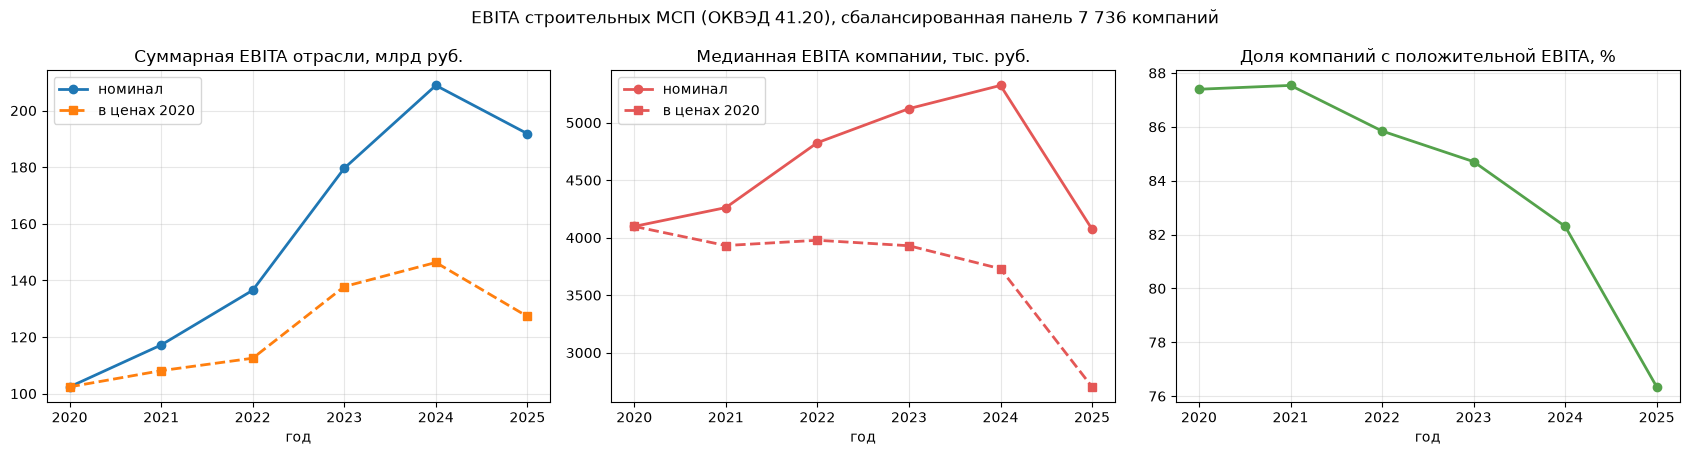

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

ax[0].plot(сводка.index, сводка["EBITA_млрд"], "o-", lw=2, label="номинал")
ax[0].plot(сводка.index, сводка["EBITA_реальная_млрд"], "s--", lw=2,
           label="в ценах 2020")
ax[0].set_title("Суммарная EBITA отрасли, млрд руб.")
ax[0].legend()

ax[1].plot(сводка.index, сводка["EBITA_медиана"], "o-", color="#E45756", lw=2,
           label="номинал")
ax[1].plot(сводка.index, сводка["EBITA_медиана"] / сводка["индекс_цен"], "s--",
           color="#E45756", lw=2, label="в ценах 2020")
ax[1].set_title("Медианная EBITA компании, тыс. руб.")
ax[1].legend()

ax[2].plot(сводка.index, сводка["доля_прибыльных_%"], "o-",
           color="#54A24B", lw=2)
ax[2].set_title("Доля компаний с положительной EBITA, %")

for a in ax:
    a.grid(alpha=.3)
    a.set_xlabel("год")
fig.suptitle("EBITA строительных МСП (ОКВЭД 41.20), сбалансированная панель "
             "7 736 компаний", fontsize=12)
fig.tight_layout()
plt.show()

Три графика говорят про отрасль разное:

1. Сумма растёт даже с поправкой на инфляцию, но в 2025 году разворачивается
   вниз.
2. Медиана в реальном выражении падает почти всё время, обычная компания
   беднеет начиная с 2021 года.
3. Доля прибыльных компаний снижается монотонно, с 87% до 76%. То есть каждая
   четвёртая компания в 2025 году убыточна уже на операционном уровне.

Медианная рентабельность по EBITA всё время держится около 3% и к 2025 году
возвращается к уровню 2020-го. Отрасль работает на очень тонкой марже, запаса
прочности у обычной компании нет.

## 6. Графики роста чистой прибыли

По условию `x` это целый процент роста чистой прибыли относительно N-летней
давности, а `y` количество компаний. Взял N = 1, 3 и 5, чтобы посмотреть и на
последний год, и на весь период.

Главная сложность тут в отрицательной базе. Обычный расчёт
`(ЧП_сейчас - ЧП_тогда) / ЧП_тогда` ломается, если раньше компания была в
убытке. Например, прибыль выросла с -500 до +1000, компания вышла из убытка, а
формула даёт `(1000 - (-500)) / (-500) = -300%`, как будто случилось падение.
Делить на отрицательное число нельзя, и обрезка значений это не исправит,
знак уже перевёрнут.

Поэтому разделил компании на три группы, и на гистограмму попадает только
первая:

1. база больше нуля, процент считается нормально
2. база не больше нуля, а стало больше нуля - "вышли из убытка", процент не
   определён
3. база не больше нуля и стало не больше нуля - "остались в убытке", процент
   не определён

Численность второй и третьей групп подписал прямо на графиках, потому что
молча их выбросить значило бы потерять треть выборки.

Ещё два решения по оформлению. Значения за пределами от -200% до +300%
загоняю в края, иначе несколько компаний с ростом в тысячи процентов растянут
ось. Шкала `y` логарифмическая, потому что около нуля компаний в разы больше,
чем на хвостах.

Самое полезное на этих графиках - вертикальная линия инфляции. С ней вопрос
"выросла ли прибыль" превращается в вопрос "обогнала ли она цены".

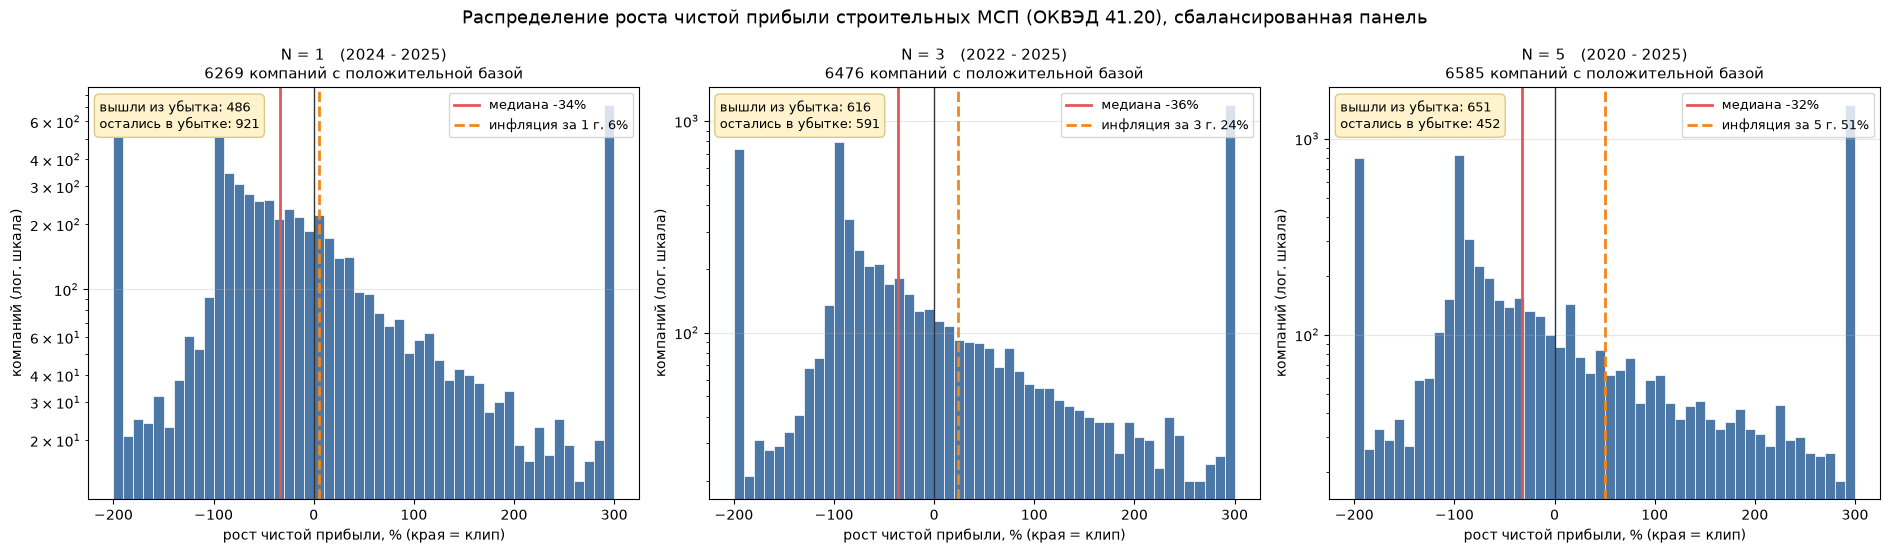

,N,период,компаний,база>0,вышли_из_убытка,остались_в_убытке,медиана_роста_%,инфляция_%,обогнали_цены_%,упали_%
0,1,2024-2025,7676,6269,486,921,-34.0,5.6,36.8,61.1
1,3,2022-2025,7683,6476,616,591,-36.0,24.2,37.7,58.1
2,5,2020-2025,7688,6585,651,452,-32.0,50.7,37.2,55.8


In [16]:
КОНЕЦ, КЛИП, ШАГ = 2025, (-200, 300), 10
чп = bal.pivot(index="ИНН", columns="год", values="2400")


def инфляция_за(лет):
    к = 1.0
    for г in range(КОНЕЦ - лет + 1, КОНЕЦ + 1):
        к *= 1 + ИПЦ[г] / 100
    return (к - 1) * 100


fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))
итоги = []

for ax, n in zip(axes, [1, 3, 5]):
    старт = КОНЕЦ - n
    пара = чп[[старт, КОНЕЦ]].dropna()
    база, сейчас = пара[старт], пара[КОНЕЦ]

    полож = база > 0
    из_убытка = (~полож) & (сейчас > 0)
    в_убытке = (~полож) & (сейчас <= 0)

    процент = ((сейчас[полож] - база[полож]) / база[полож] * 100).round()
    медиана, инфл = процент.median(), инфляция_за(n)

    итоги.append({"N": n, "период": f"{старт}-{КОНЕЦ}", "компаний": len(пара),
                  "база>0": int(полож.sum()),
                  "вышли_из_убытка": int(из_убытка.sum()),
                  "остались_в_убытке": int(в_убытке.sum()),
                  "медиана_роста_%": медиана, "инфляция_%": round(инфл, 1),
                  "обогнали_цены_%": round((процент > инфл).mean() * 100, 1),
                  "упали_%": round((процент < 0).mean() * 100, 1)})

    ax.hist(процент.clip(*КЛИП), bins=np.arange(КЛИП[0], КЛИП[1] + ШАГ, ШАГ),
            color="#4C78A8", edgecolor="white", linewidth=.5)
    ax.axvline(0, color="#333", lw=1)
    ax.axvline(медиана, color="#E45756", lw=2, label=f"медиана {медиана:.0f}%")
    ax.axvline(инфл, color="#F58518", lw=2, ls="--",
               label=f"инфляция за {n} г. {инфл:.0f}%")
    ax.set_yscale("log")
    ax.set_title(f"N = {n}   ({старт} - {КОНЕЦ})\n"
                 f"{len(процент)} компаний с положительной базой", fontsize=11)
    ax.set_xlabel("рост чистой прибыли, % (края = клип)")
    ax.set_ylabel("компаний (лог. шкала)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=.3)
    ax.text(.02, .97, f"вышли из убытка: {из_убытка.sum()}\n"
                      f"остались в убытке: {в_убытке.sum()}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=.4", fc="#FFF3CD", ec="#E0C97F"))

fig.suptitle("Распределение роста чистой прибыли строительных МСП "
             "(ОКВЭД 41.20), сбалансированная панель", fontsize=13)
fig.tight_layout()
plt.show()

display(pd.DataFrame(итоги))

Распределение на всех трёх горизонтах смещено влево, это видно и по форме, и
по числам:

* медиана роста отрицательная везде: -34% за год, -36% за три года, -32% за
  пять лет
* красная линия медианы всегда левее оранжевой линии инфляции, на пятилетнем
  горизонте разрыв доходит до 80 процентных пунктов
* цены обогнали только около 37% компаний на любом горизонте, то есть почти
  две трети отрасли по чистой прибыли отстали от инфляции
* в номинале упали 56-61% компаний

Заметный пик у отметки -100% это компании, у которых прибыль обнулилась. На
однолетнем горизонте таких особенно много, и вместе с ростом группы "остались
в убытке" (921 компания против 452 на пятилетнем горизонте) это говорит о том,
что 2025 год оказался для отрасли тяжелее предыдущих.

Одна вещь работает в обратную сторону: 486-651 компаний вышли из убытка. Так
что отрасль не деградирует однородно, внутри неё идёт заметная перетасовка и
часть компаний своё положение улучшает.

## 7. Карта топ-500 по выручке

Беру топ-500 по выручке за 2024 год, а не за 2025-й: у 2025 покрытие 82%, и
рейтинг по нему был бы рейтингом "кто успел отчитаться". Строки, помеченные
раньше как подозрительные, исключил.

С адресами пришлось решить три проблемы.

**Адрес собирается цепочкой.** Ни одно поле не заполнено у всех компаний. У
Москвы и Санкт-Петербурга город отдельно не указан, потому что это города
федерального значения и регион там и есть город. У части компаний вместо
города заполнен район. Поэтому иду по цепочке
`город -> населённый пункт -> район -> регион`.

**Адрес из БФО местами неверный.** Сначала брал адреса из БФО, они подробнее.
Потом заметил странность: 8 компаний из топ-500 числились в Грозном, среди них
"ОМСКАГРОПРОМСТРОЙ" с ИНН на 55 (код Омской области) и "РВД-3" с ИНН на 40
(Калужская область). Подумал, что при сборе подставилась чужая организация,
ведь в коде берётся `content[0]` без проверки ИНН. Сделал прямой запрос к API
и убедился, что это не так: по каждому ИНН находится ровно одна организация и
её ИНН совпадает с запрошенным. Значит компании найдены правильно, а неверен
сам адрес в БФО. Всего регион БФО расходится с реестром у 34 компаний из 500.
Реестр ФНС в этих случаях сходится и с префиксом ИНН, и с названием компании,
поэтому адреса беру из реестра, а БФО оставляю запасным вариантом.

**Отказ сервиса выглядит как отсутствие данных.** Первым геокодером взял
Nominatim. После примерно 50 запросов он начал возвращать пустые ответы, причём
на любые запросы, включая "Омск" и "Грозный". Со стороны это выглядело как
дырявые исходные данные. Проверил код ответа - оказалось 429 Too many requests,
то есть превышен лимит в 1 запрос в секунду. Отсюда вывод на будущее: пустой
ответ API нельзя считать отсутствием данных, пока не проверишь код ответа,
иначе в выборке появятся пропуски, которых в источнике нет. Значения, попавшие
в кэш из-за отказов, пришлось выбросить и запросить заново уже через Photon.
Он работает на тех же данных OpenStreetMap, ключа не требует и к нагрузке
терпимее.

In [17]:
ГОД_КАРТЫ, СКОЛЬКО = 2024, 500
КЭШ, CSV_ТОП = "геокэш.json", "топ500_с_координатами.csv"
PHOTON = "https://photon.komoot.io/api"


def место_компании(строка):
    for поле in ["город_реестр", "нп_реестр", "район_реестр",
                 "город_бфо", "нп_бфо", "район_бфо"]:
        значение = строка.get(поле)
        if pd.notna(значение) and str(значение).strip():
            return str(значение).strip()
    return строка["регион_чист"]


def нормализовать(место):
    место = re.sub(r"^(г|п|с|д|пос|рп)(\.\s*|\s+)|\s+(г|п|с|д)\.?$", "",
                   str(место).strip())
    return re.sub(r"\s*(р-н|район)\s*", " ", место).strip()


def геокодировать(место, регион, сессия):
    for запрос in [f"{место}, {регион}", место, регион]:
        if "None" in str(запрос):
            continue
        ответ = сессия.get(PHOTON, params={"q": запрос, "limit": 5,
                                           "osm_tag": "place"}, timeout=30)
        if ответ.status_code == 429:
            time.sleep(5)
            continue
        time.sleep(1)
        if ответ.status_code != 200:
            continue
        for точка in ответ.json().get("features", []):
            if точка.get("properties", {}).get("countrycode") == "RU":
                долгота, широта = точка["geometry"]["coordinates"]
                return широта, долгота
    return None


if os.path.exists(CSV_ТОП):
    top = pd.read_csv(CSV_ТОП, dtype={"ИНН": str})
    print(f"прочитано из {CSV_ТОП}: {len(top)} компаний")
else:
    top = panel[(panel["год"] == ГОД_КАРТЫ) & ~panel["подозрительная"]
                & panel["2110"].notna()].nlargest(СКОЛЬКО, "2110").copy()
    top["регион_чист"] = top["регион_реестр"].str.split(" - ").str[-1]
    top["место"] = top.apply(место_компании, axis=1).map(нормализовать)
    top["ключ"] = top["место"] + "|" + top["регион_чист"].fillna("")

    кэш = {}
    if os.path.exists(КЭШ):
        with open(КЭШ, encoding="utf-8") as f:
            кэш = {k: v for k, v in json.load(f).items() if v}

    надо = [k for k in top["ключ"].unique() if k not in кэш]
    print(f"уникальных мест: {top['ключ'].nunique()}, запросить: {len(надо)}")

    сессия = requests.Session()
    сессия.headers.update({"User-Agent": "okved-41-20-lab/1.0"})
    for i, ключ in enumerate(надо, 1):
        место, регион = ключ.split("|", 1)
        координаты = геокодировать(место, регион, сессия)
        if координаты:
            кэш[ключ] = list(координаты)
        if i % 25 == 0 or i == len(надо):
            with open(КЭШ, "w", encoding="utf-8") as f:
                json.dump(кэш, f, ensure_ascii=False, indent=1)
            print(f"  {i}/{len(надо)}")

    top["широта"] = top["ключ"].map(lambda k: (кэш.get(k) or [None, None])[0])
    top["долгота"] = top["ключ"].map(lambda k: (кэш.get(k) or [None, None])[1])
    top.to_csv(CSV_ТОП, index=False, encoding="utf-8-sig")

top = top[top["широта"].notna()].copy()
top["выручка_млрд"] = top["2110"] / 1e6
top["EBITA_млн"] = top["EBIT"] / 1e3
print(f"с координатами: {len(top)}/{СКОЛЬКО}")
print(f"выручка топ-500: от {top['выручка_млрд'].min():.2f} "
      f"до {top['выручка_млрд'].max():.2f} млрд руб.")

прочитано из топ500_с_координатами.csv: 500 компаний
с координатами: 500/500
выручка топ-500: от 1.36 до 14.35 млрд руб.


Первая карта показывает отдельные компании. Компании из одного города имеют
одинаковые координаты и слились бы в одну точку, поэтому раздвигаю их
небольшим случайным сдвигом. Seed зафиксирован, чтобы карта не менялась при
каждом запуске. Размер точки беру как корень из выручки, иначе крупнейшая
компания была бы в десять раз больше остальных и закрыла бы карту.

In [18]:
случайно = np.random.default_rng(42)
top["шир_сдвиг"] = top["широта"] + случайно.normal(0, 0.06, len(top))
top["дол_сдвиг"] = top["долгота"] + случайно.normal(0, 0.09, len(top))
top["размер"] = np.sqrt(top["выручка_млрд"])

карта1 = px.scatter_map(
    top, lat="шир_сдвиг", lon="дол_сдвиг", size="размер", size_max=26,
    color="выручка_млрд", color_continuous_scale="Turbo",
    hover_name="наименование",
    hover_data={"ИНН": True, "место": True, "регион_чист": True,
                "выручка_млрд": ":.2f", "EBITA_млн": ":.0f",
                "шир_сдвиг": False, "дол_сдвиг": False, "размер": False},
    zoom=2.6, center={"lat": 58, "lon": 75}, map_style="open-street-map",
    height=720,
    title=f"Топ-500 строительных МСП по выручке за {ГОД_КАРТЫ} г.")
карта1.update_layout(margin=dict(l=0, r=0, t=48, b=0),
                     coloraxis_colorbar_title="выручка,<br>млрд руб.")
карта1.write_html("карта_топ500_компании.html", include_plotlyjs="cdn")
карта1.show()

Вторая карта удобнее для вывода о концентрации: размер пузыря это суммарная
выручка города. Группирую города по координатам, а не по названию, потому что
одно и то же место приходит из разных источников в разном написании ("Уфа" и
"УФА"), и группировка по строке разложила бы город на два пузыря в одной точке.

In [19]:
города = (top.groupby(["широта", "долгота"], as_index=False)
          .agg(место=("место", lambda s: s.mode().iat[0].title()),
               регион=("регион_чист", lambda s: s.mode().iat[0]),
               компаний=("ИНН", "count"),
               выручка_млрд=("выручка_млрд", "sum"),
               EBITA_млн=("EBITA_млн", "sum"))
          .sort_values("выручка_млрд", ascending=False))
города["размер"] = np.sqrt(города["выручка_млрд"])

карта2 = px.scatter_map(
    города, lat="широта", lon="долгота", size="размер", size_max=52,
    color="компаний", color_continuous_scale="Turbo", hover_name="место",
    hover_data={"регион": True, "компаний": True, "выручка_млрд": ":.1f",
                "EBITA_млн": ":.0f", "широта": False, "долгота": False,
                "размер": False},
    zoom=2.6, center={"lat": 58, "lon": 75}, map_style="open-street-map",
    height=720,
    title=f"Суммарная выручка топ-500 по городам регистрации, {ГОД_КАРТЫ} г.")
карта2.update_layout(margin=dict(l=0, r=0, t=48, b=0),
                     coloraxis_colorbar_title="компаний")
карта2.write_html("карта_топ500_города.html", include_plotlyjs="cdn")
карта2.show()

In [20]:
всего = top["выручка_млрд"].sum()
print(f"суммарная выручка топ-500: {всего:.0f} млрд руб.")
print(f"городов: {len(города)}, регионов: {top['регион_чист'].nunique()} из 89")
print(f"первые 5 городов дают "
      f"{города.head(5)['выручка_млрд'].sum() / всего:.1%} выручки топ-500\n")
display(города.head(12)[["место", "регион", "компаний", "выручка_млрд",
                         "EBITA_млн"]].round(1))

display(top.groupby("регион_чист")
        .agg(компаний=("ИНН", "count"), выручка_млрд=("выручка_млрд", "sum"))
        .sort_values("выручка_млрд", ascending=False).head(10).round(1))

суммарная выручка топ-500: 1186 млрд руб.
городов: 155, регионов: 69 из 89
первые 5 городов дают 43.5% выручки топ-500



,место,регион,компаний,выручка_млрд,EBITA_млн
94,Москва,г.Москва,111,287.1,18861.7
139,Санкт-Петербург,г.Санкт-Петербург,40,93.3,5356.4
98,Казань,Республика Татарстан (Татарстан),19,52.7,2500.4
115,Екатеринбург,Свердловская область,24,46.4,2117.1
71,Новосибирск,Новосибирская область,13,36.8,990.3
17,Краснодар,Краснодарский край,13,31.9,1559.3
66,Уфа,Республика Башкортостан,9,17.9,600.8
128,Коммунарка,г.Москва,2,16.5,2979.2
100,Химки,Московская область,5,15.8,374.8
103,Красноярск,Красноярский край,8,14.7,-613.6


,компаний,выручка_млрд
регион_чист,,
г.Москва,119,316.0
г.Санкт-Петербург,44,103.0
Республика Татарстан (Татарстан),31,79.7
Московская область,31,77.6
Свердловская область,29,56.6
Краснодарский край,20,45.8
Новосибирская область,13,34.9
Калужская область,6,26.6
Приморский край,8,21.2


География крупного строительного бизнеса сильно сконцентрирована: первые пять
городов дают больше 40% выручки топ-500, а в одной Москве зарегистрировано
больше сотни компаний из пятисот. Регионы представлены далеко не все.

Тут важна оговорка: карта построена по месту регистрации, а не по месту
стройки. Для Москвы это расхождение особенно велико, компания может быть
зарегистрирована в столице, а строить в другом регионе. Так что карта
показывает, где сидят центры принятия решений и деньги, а не где стоят
стройплощадки.

Интересно сравнить с разделом 5. По компаниям концентрация низкая, топ-10 дают
всего 3,9% выручки панели, а по географии высокая. То есть отрасль состоит из
множества небольших игроков, но скучены они в нескольких точках на карте.

## 8. Выводы

Агрегатные показатели растут, но экономика обычной компании ухудшается. По
совокупности признаков отрасль выглядит скорее стагнирующей, чем
перспективной.

За рост говорит:

* суммарная EBITA выросла на 87% за 2020-2025, и даже за вычетом инфляции на
  24%
* суммарная выручка выросла на 58% номинально
* 486-651 компаний вышли из убытка, то есть успешные истории внутри отрасли
  есть

Против:

* медианная EBITA выросла на -0,6% за пять лет, в реальном выражении обычная
  компания потеряла около трети прибыли
* медиана роста чистой прибыли отрицательная на всех горизонтах, от -32% до
  -36%, а инфляцию обогнали только 37% компаний
* доля прибыльных компаний упала с 87% до 76%, то есть каждая четвёртая
  убыточна уже на операционном уровне
* медианная рентабельность по EBITA около 3% и не растёт, к 2025 году она
  вернулась к уровню 2020-го
* 2025 год это разворот: суммарная EBITA упала на 8%, медианная на 24%, доля
  прибыльных на 6 пунктов

Расхождение суммы и медианы объясняется не несколькими гигантами, концентрация
в отрасли низкая. Рост суммы создан нижним и средним сегментом с эффектом
низкой базы, а у трёх верхних групп из пяти медианная EBITA снизилась.

Итог: отрасль подходит действующим игрокам с отработанной нишей, но для входа
нового участника выглядит непривлекательно. Маржа тонкая, доля убыточных
растёт, а последний год отрицательный по всем ключевым метрикам.

### Что проверял по ходу работы

* EBITA примерно равна EBIT для строительных МСП - подтвердилось, НМА 0,09%
  активов, у 96% компаний ноль
* рост прибыли отрасли инфляционный - подтвердилось частично, сумма растёт и
  реально (+24%), а медиана нет
* сумму вытягивают несколько гигантов - не подтвердилось, топ-10 дают 3,9%
* 2300 восстанавливается как 2400 - 2410 - не подтвердилось, знак 2410
  непостоянен, нужна формула через 2340 и 2350
* при сборе подставилась чужая организация - не подтвердилось, ИНН совпадают,
  неверен адрес в БФО

### Ограничения

По данным и выборке:

1. Survivorship bias, это главное ограничение. В реестре МСП только
   действующие компании, обанкротившиеся и ликвидированные в выборку не
   попали. В разделе 5 это видно прямо: медиана EBITA на сбалансированной
   панели выше, чем по всем собранным компаниям. Значит реальная картина
   отрасли хуже.
2. Микропредприятия исключены по условию задания, взяты только малые и
   средние. Это самая массовая часть строительного бизнеса, и выводы на неё не
   переносятся.
3. 93 компании (0,9%) отсутствуют в БФО, в основном недавно
   зарегистрированные.
4. Покрытие 2025 года 82%, поэтому вся динамика считалась на сбалансированной
   панели из 7 736 компаний.
5. ОКВЭД в БФО расходится с реестром у 13,7% компаний. Основным считал реестр.
6. Адреса в БФО неверные у 34 компаний из 500 в топ-выборке, поэтому адреса
   взяты из реестра.
7. 957 строк (1,6%) помечены подозрительными и исключены вместе с 440
   компаниями: отрицательная выручка или себестоимость, скачок выручки больше
   чем в 20 раз относительно своей медианы.

По методике:

8. EBIT вместо EBITA. Обосновано измерением в разделе 4, но формально это всё
   же приближение.
9. Код 2460 "Прочее" через API недоступен, из-за чего тождество
   `2400 = 2300 + 2410` не сходится у 27% строк полной формы. На EBIT это не
   влияет, там 2300 берётся из отчёта.
10. ИПЦ декабрь к декабрю как дефлятор это упрощение. Выручка и прибыль это
    потоки за год, для них точнее подошёл бы среднегодовой индекс. К тому же
    общий ИПЦ не учитывает, что цены в строительстве росли иначе, чем
    потребительские.
11. Отчётность не консолидирована, компании одной группы считаются раздельно
    и расчёты между ними не исключены.

По карте:

12. Место регистрации не равно месту работы, для Москвы расхождение особенно
    велико.
13. Геокодирование до города, а не до адреса. Для Москвы и Санкт-Петербурга
    координата это центр города.

### Ссылки

* реестр МСП - https://rmsp.nalog.ru/
* ГИР БФО - https://bo.nalog.gov.ru/
* ИПЦ - https://rosstat.gov.ru/statistics/price
* карты plotly - https://plotly.com/python/tile-map-layers/
* Photon - https://photon.komoot.io/